In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [3]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 32

SEED = 42

dataset_path = "/workspaces/plant_disease_detection/data/raw"

In [5]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [6]:
class_names = validation_dataset.class_names

print(class_names)

print("Number of Classes:",
      len(class_names))

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of Classes: 15


In [8]:
model = tf.keras.models.load_model(
    "/workspaces/plant_disease_detection/artifacts/best_model.keras"
)

In [9]:
loss, accuracy = model.evaluate(
    validation_dataset
)

print(f"Validation Loss: {loss:.4f}")

print(f"Validation Accuracy: {accuracy*100:.2f}%")

129/129 ━━━━━━━━━━━━━━━━━━━━ 37s 285ms/step - accuracy: 0.6697 - loss: 0.9960
Validation Loss: 0.9960
Validation Accuracy: 66.97%


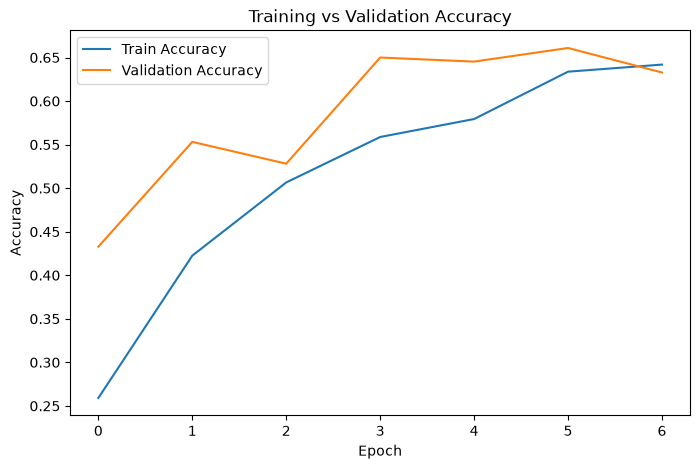

In [11]:
import pickle

with open('../artifacts/history.pkl', 'rb') as file: 
    history = pickle.load(file) 
    plt.figure(figsize=(8,5)) 
    plt.plot(history['accuracy'], 
             label='Train Accuracy') 
    plt.plot(history['val_accuracy'], 
             label='Validation Accuracy') 
    plt.title('Training vs Validation Accuracy')
    plt.xlabel('Epoch') 
    plt.ylabel('Accuracy') 
    plt.legend() 
    plt.show()

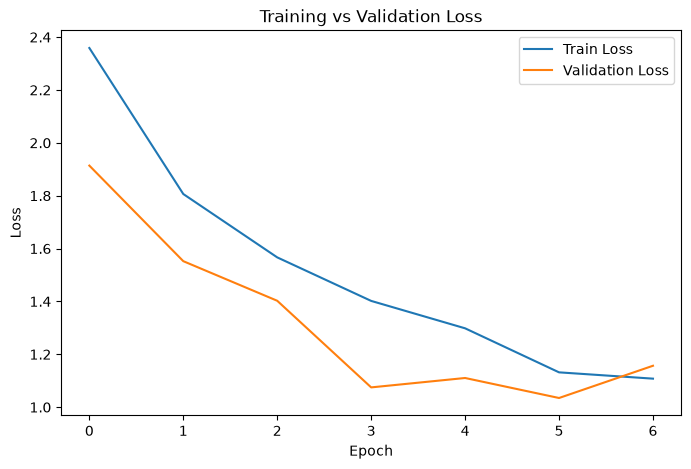

In [12]:
plt.figure(figsize=(8,5)) 
plt.plot(history['loss'], 
         label='Train Loss') 
plt.plot(history['val_loss'], 
         label='Validation Loss')
plt.title('Training vs Validation Loss') 
plt.xlabel('Epoch') 
plt.ylabel('Loss') 
plt.legend() 
plt.show()

In [13]:
y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images)

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [14]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm.shape)

(15, 15)


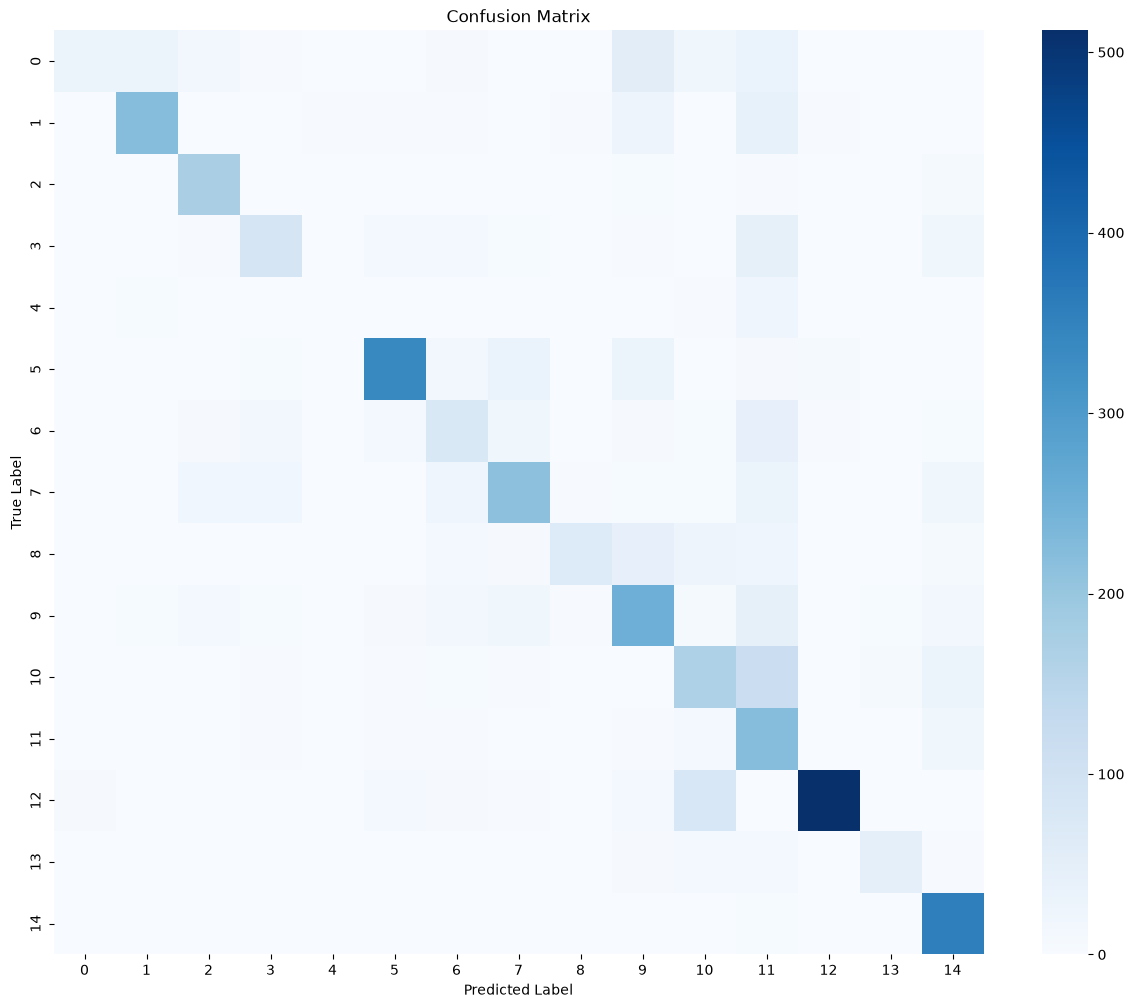

In [15]:
plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.savefig(
    "../artifacts/confusion_matrix.png"
)

plt.show()

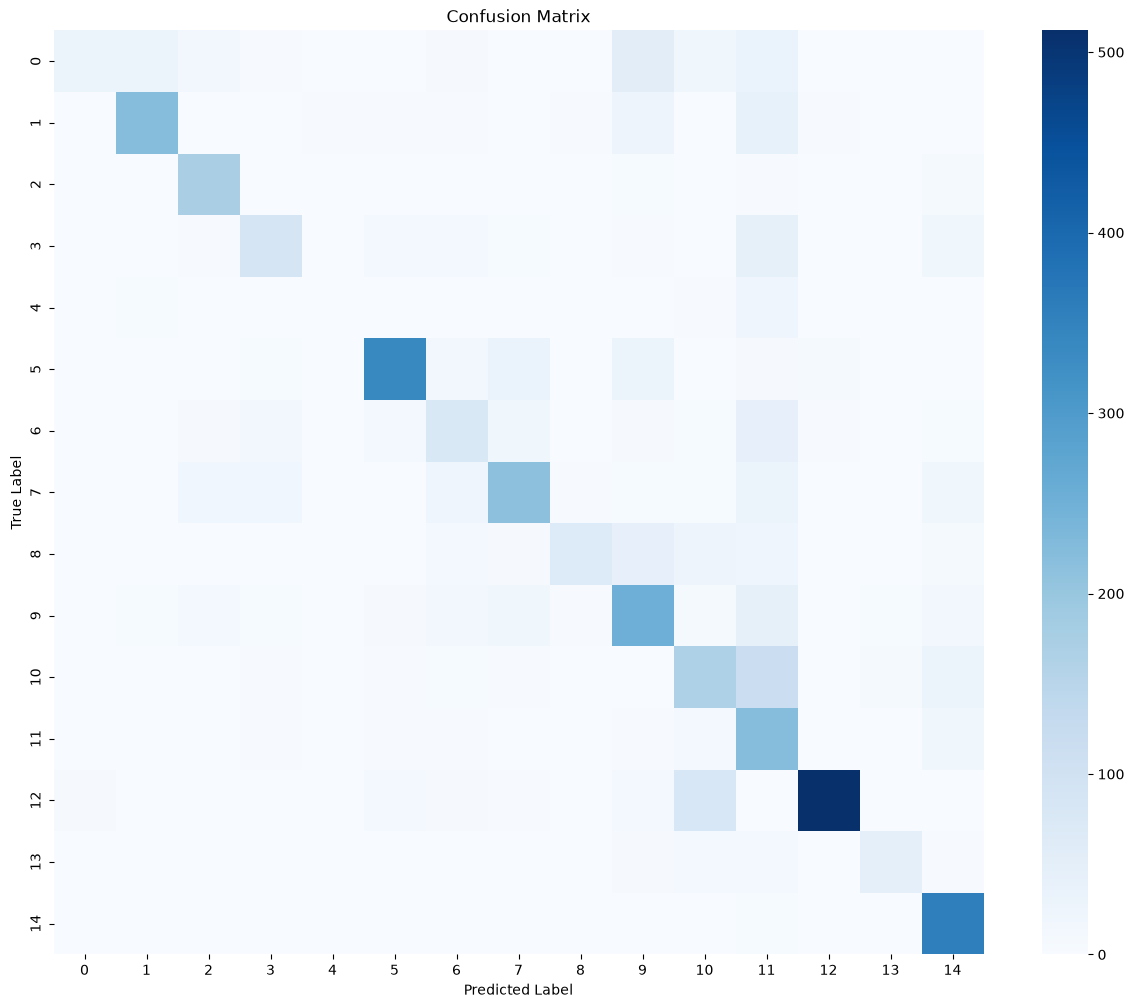

In [16]:
plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.savefig(
    "../artifacts/confusion_matrix.png"
)

plt.show()

In [17]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.76      0.15      0.26       200
                     Pepper__bell___healthy       0.84      0.73      0.78       302
                      Potato___Early_blight       0.74      0.91      0.82       189
                       Potato___Late_blight       0.64      0.47      0.54       188
                           Potato___healthy       0.00      0.00      0.00        31
                      Tomato_Bacterial_spot       0.87      0.76      0.81       441
                        Tomato_Early_blight       0.42      0.40      0.41       191
                         Tomato_Late_blight       0.70      0.63      0.66       341
                           Tomato_Leaf_Mold       0.87      0.36      0.51       185
                  Tomato_Septoria_leaf_spot       0.56      0.64      0.60       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.50      0.50

In [18]:
with open(
    "../artifacts/classification_report.txt",
    "w"
) as f:

    f.write(report)